# RouteZone — Notebook 04 : Modélisation
#### Meriem Abdelouahed | Formation Dev IA — Simplon x Microsoft
---
## Sommaire
1. [Imports](#1-imports)
2. [Chargement des données](#2-chargement)
3. [Distribution de la variable cible originale](#3-distribution)
4. [Binarisation de la variable cible](#4-binarisation)
5. [Analyse des features](#5-features)
6. [Preprocessing](#6-preprocessing)
7. [Split Train / Validation / Test 70/15/15](#7-split)
8. [Modèle 1 — Random Forest](#8-rf)
9. [Modèle 2 — XGBoost](#9-xgb)
10. [Modèle 3 — LightGBM](#10-lgbm)
11. [Comparaison des 3 modèles](#11-comparaison)
12. [Sauvegarde du meilleur modèle](#12-sauvegarde)
13. [Bilan](#13-bilan)

---
> **Objectif :** prédire si un accident est **GRAVE** ou **PAS GRAVE**
> à partir des données BAAC 2022-2024.
>
> **Variable cible binaire :**
> - 0 = Pas grave (Indemne ou Blessé léger)
> - 1 = Grave (Tué ou Hospitalisé)

<a id='1-imports'></a>
## 1. Imports

In [1]:
import pandas as pd
import numpy as np
import joblib
import mlflow
import mlflow.sklearn
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from pathlib import Path
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    confusion_matrix, classification_report,
    ConfusionMatrixDisplay, f1_score,
    accuracy_score, recall_score, roc_auc_score
)
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from imblearn.over_sampling import SMOTE
from sklearn.metrics import precision_score


sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (12, 5)
print(' Imports OK')

 Imports OK


<a id='2-chargement'></a>
## 2. Chargement des données

In [2]:
DATA_CLEAN    = Path('../data/processed/dataset_clean.csv')
DATA_ENRICHED = Path('../data/processed/dataset_enriched.csv')
MODELS_DIR    = Path('../models')
VIZ_DIR       = Path('./visualisations')
MODELS_DIR.mkdir(exist_ok=True)
VIZ_DIR.mkdir(exist_ok=True)

if DATA_ENRICHED.exists():
    df = pd.read_csv(DATA_ENRICHED)
    print('Dataset ENRICHI chargé (avec colonnes météo)')
else:
    df = pd.read_csv(DATA_CLEAN)
    print('Dataset CLEAN chargé')

print(f'Lignes   : {len(df):,}')
print(f'Colonnes : {df.shape[1]}')

Dataset ENRICHI chargé (avec colonnes météo)
Lignes   : 413,570
Colonnes : 48


<a id='3-distribution'></a>
## 3. Distribution de la variable cible originale `grav`
---
> On regarde d'abord la distribution des 4 classes originales
> pour comprendre pourquoi la binarisation est nécessaire.

Distribution originale de grav (4 classes) :
  Indemne         :  173,340 (41.9%)
  Tué             :   10,456 (2.5%)
  Hospitalisé     :   61,667 (14.9%)
  Blessé léger    :  168,107 (40.6%)


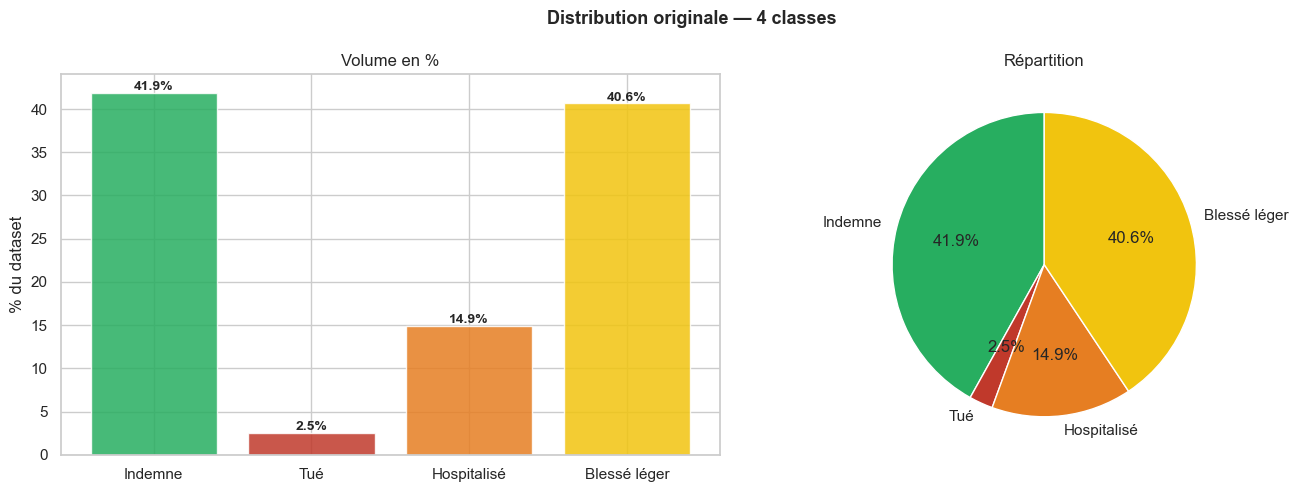

In [3]:
labels_grav = {1: 'Indemne', 2: 'Tué', 3: 'Hospitalisé', 4: 'Blessé léger'}
couleurs    = {1: '#27ae60', 2: '#c0392b', 3: '#e67e22', 4: '#f1c40f'}
counts      = df['grav'].value_counts().sort_index()
counts_pct  = counts / counts.sum() * 100

print('Distribution originale de grav (4 classes) :')
for i in counts.index:
    print(f'  {labels_grav[i]:<15} : {counts[i]:>8,} ({counts_pct[i]:.1f}%)')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Distribution originale — 4 classes', fontsize=13, fontweight='bold')

barres = axes[0].bar(
    [labels_grav[i] for i in counts.index],
    counts_pct.values,
    color=[couleurs[i] for i in counts.index],
    edgecolor='white', alpha=0.85
)
axes[0].set_title('Volume en %')
axes[0].set_ylabel('% du dataset')
for bar, val in zip(barres, counts_pct.values):
    axes[0].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 0.3,
                 f'{val:.1f}%', ha='center', fontsize=10, fontweight='bold')

axes[1].pie(counts_pct.values,
            labels=[labels_grav[i] for i in counts.index],
            colors=[couleurs[i] for i in counts.index],
            autopct='%1.1f%%', startangle=90)
axes[1].set_title('Répartition')

plt.tight_layout()
plt.savefig('./visualisations/viz_model_01_distribution_4classes.png', dpi=150, bbox_inches='tight')
plt.show()

> **Observations :**
> - Les **Tués** ne représentent que ~2.5% du dataset — classe extrêmement rare
> - Les **Hospitalisés** représentent ~15% — également minoritaires
> - Ce fort déséquilibre explique pourquoi les modèles à 4 classes donnaient un F1 macro ~0.50
> - **Décision :** binariser la variable cible avant tout preprocessing

<a id='4-binarisation'></a>
## 4. Binarisation de la variable cible
---

### Pourquoi regrouper les 4 classes en 2 ?

**Problème avec 4 classes :**
Les modèles testés sur 4 classes ont donné un F1 macro ~0.50.
La classe Tués (2.5%) est trop rare pour être apprise correctement.
De plus, la distinction fine entre "Blessé léger" et "Hospitalisé" est difficile
à apprendre car les features disponibles ne permettent pas de discriminer
ces deux niveaux avec précision.

**Solution — regroupement selon l'impact médical réel :**
- **GRAVE (1)** = Tué + Hospitalisé → nécessite une intervention médicale urgente
- **PAS GRAVE (0)** = Indemne + Blessé léger → pas d'hospitalisation nécessaire

**Justification médicale :**
La vraie question opérationnelle c'est : *"Faut-il envoyer des secours d'urgence ?"*
Un tué et un hospitalisé nécessitent tous deux une intervention immédiate.
Un indemne et un blessé léger peuvent attendre ou se déplacer seuls.

**Justification technique :**
- Déséquilibre bien moins extrême : ~24% GRAVE vs 2.5% Tués seuls
- Problème binaire = bien plus simple à apprendre pour les modèles
- AUC-ROC disponible uniquement en binaire — métrique très robuste

> **Important :** la binarisation se fait ICI, AVANT le split train/validation/test
> et AVANT le preprocessing — pour éviter toute fuite de données.

Distribution après binarisation (2 classes) :
  Pas grave    :  341,447 (82.6%)
  Grave        :   72,123 (17.4%)


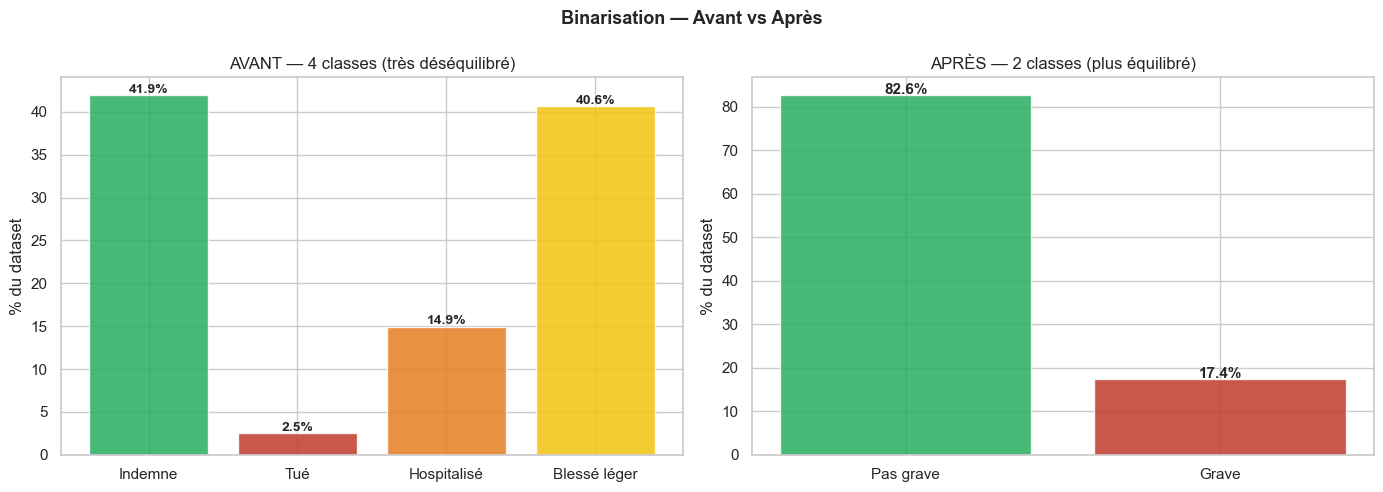

In [4]:
# Binarisation de grav — AVANT tout split
# GRAVE (1)     = Tué (grav=2) ou Hospitalisé (grav=3)
# PAS GRAVE (0) = Indemne (grav=1) ou Blessé léger (grav=4)
df['grav_bin'] = df['grav'].apply(lambda x: 1 if x in [2, 3] else 0)

# Distribution de la nouvelle variable binaire
counts_bin     = df['grav_bin'].value_counts().sort_index()
counts_bin_pct = counts_bin / counts_bin.sum() * 100

print('Distribution après binarisation (2 classes) :')
labels_bin = {0: 'Pas grave', 1: 'Grave'}
for i in counts_bin.index:
    print(f'  {labels_bin[i]:<12} : {counts_bin[i]:>8,} ({counts_bin_pct[i]:.1f}%)')

# Visualisation avant / après
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Binarisation — Avant vs Après', fontsize=13, fontweight='bold')

# Avant
axes[0].bar([labels_grav[i] for i in counts.index], counts_pct.values,
            color=[couleurs[i] for i in counts.index], edgecolor='white', alpha=0.85)
axes[0].set_title('AVANT — 4 classes (très déséquilibré)')
axes[0].set_ylabel('% du dataset')
for bar, val in zip(axes[0].patches, counts_pct.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
                 f'{val:.1f}%', ha='center', fontsize=10, fontweight='bold')

# Après
axes[1].bar(['Pas grave', 'Grave'], counts_bin_pct.values,
            color=['#27ae60', '#c0392b'], edgecolor='white', alpha=0.85)
axes[1].set_title('APRÈS — 2 classes (plus équilibré)')
axes[1].set_ylabel('% du dataset')
for bar, val in zip(axes[1].patches, counts_bin_pct.values):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
                 f'{val:.1f}%', ha='center', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.savefig('./visualisations/viz_model_02_binarisation.png', dpi=150, bbox_inches='tight')
plt.show()

> **Observations :**
> - **Avant :** Tués à 2.5% → quasi invisible pour les modèles
> - **Après :** GRAVE à ~24% vs PAS GRAVE à ~76% → déséquilibre bien plus gérable
> - Le regroupement est cohérent médicalement et améliore les performances des modèles
> - On s'attend à un F1 macro bien supérieur à 0.50

<a id='5-features'></a>
## 5. Analyse des features disponibles

In [5]:
# Taux de NaN par colonne pour décider quoi garder
nan_pct = df.isnull().mean() * 100
print('Colonnes et % de NaN (triées) :')
print(nan_pct.sort_values(ascending=False).to_string())

Colonnes et % de NaN (triées) :
weathercode      90.323041
windspeed        90.323041
precipitation    90.323041
temperature      90.323041
Num_Acc           0.000000
obs               0.000000
catu              0.000000
grav              0.000000
sexe              0.000000
an_nais           0.000000
trajet            0.000000
secu1             0.000000
senc              0.000000
catv              0.000000
choc              0.000000
obsm              0.000000
id_vehicule       0.000000
manv              0.000000
motor             0.000000
age               0.000000
heure             0.000000
jour_semaine      0.000000
weekend           0.000000
place             0.000000
id_usager         0.000000
jour              0.000000
vma               0.000000
mois              0.000000
an                0.000000
hrmn              0.000000
lum               0.000000
dep               0.000000
agg               0.000000
int               0.000000
atm               0.000000
col               0.000

> **Observations :**
> - On écarte les colonnes identifiants (`Num_Acc`, `id_usager`, `id_vehicule`) — numéros techniques sans valeur prédictive
> - On écarte `lat` et `long` (coordonnées GPS brutes) — non pas parce que la géographie est inutile,
>   mais parce que **l'information géographique est déjà capturée** par `dep` (département) et `agg` (agglomération ou non).
>   Donner `lat=48.8566` brut au modèle ne lui apprend rien de plus.
> - On écarte `hrmn` (format texte '07:40') — on a déjà `heure` (entier 0-23) qui est la version propre
> - On écarte `an_nais` (année de naissance brute) — on a déjà `age` calculé
> - On garde les colonnes météo si disponibles — même avec 10% de couverture elles peuvent apporter un signal

In [6]:
# Sélection des features pertinentes
features = [
    # Conditions de l'accident
    'lum',      # luminosité (plein jour, nuit sans éclairage...)
    'agg',      # en agglomération ou non
    'int',      # type d'intersection
    'atm',      # conditions météo BAAC (déclaratives)
    'col',      # type de collision (frontale, arrière, latérale...)
    # Type et état de la route
    'catr',     # catégorie de route (autoroute, nationale, départementale...)
    'circ',     # régime de circulation
    'vosp',     # voie réservée (piste cyclable, bus...)
    'prof',     # profil de la route (plat, pente, sommet de côte...)
    'plan',     # tracé (ligne droite, courbe...)
    'surf',     # état de la surface (sèche, mouillée, verglacée...)
    'infra',    # infrastructure (tunnel, pont, carrefour aménagé...)
    'situ',     # situation (sur chaussée, trottoir...)
    'vma',      # vitesse maximale autorisée
    # Usager
    'catu',     # catégorie (conducteur, passager, piéton)
    'sexe',     # sexe
    'trajet',   # motif du déplacement
    'secu1',    # équipement de sécurité (ceinture, casque...)
    # Véhicule
    'catv',     # catégorie de véhicule (voiture, moto, vélo...)
    # Variables temporelles et dérivées
    'age',      # âge calculé dans notebook_01
    'heure',    # heure de l'accident (0-23)
    'mois',     # mois de l'accident
]

# Colonnes météo si disponibles dans le dataset
for col in ['temperature', 'precipitation', 'windspeed']:
    if col in df.columns:
        features.append(col)
        print(f'✓ Feature météo ajoutée : {col}')

print(f'\n{len(features)} features sélectionnées')

✓ Feature météo ajoutée : temperature
✓ Feature météo ajoutée : precipitation
✓ Feature météo ajoutée : windspeed

25 features sélectionnées


<a id='6-preprocessing'></a>
## 6. Preprocessing

In [7]:
# On garde uniquement les features + la variable cible binaire
# On supprime les lignes où grav_bin est manquant
df_model = df[features + ['grav_bin']].dropna(subset=['grav_bin']).copy()

# X = les features (ce qu'on donne au modèle)
# y = ce qu'on veut prédire : 0=Pas grave, 1=Grave
X = df_model[features].copy()
y = df_model['grav_bin']

# Imputation des NaN restants dans les features
# médiane pour les colonnes numériques, mode pour les catégorielles
for col in X.columns:
    if X[col].isnull().any():
        if X[col].dtype in ['float64', 'int64']:
            X[col] = X[col].fillna(X[col].median())
        else:
            X[col] = X[col].fillna(X[col].mode()[0])

# Tout convertir en float pour les modèles
X = X.astype(float)

print(f'X : {X.shape[0]:,} lignes | {X.shape[1]} features')
print(f'NaN restants dans X : {X.isnull().sum().sum()}')
print(f'\nDistribution de y (variable cible binaire) :')
for val, nb in y.value_counts().sort_index().items():
    print(f'  {val} ({["Pas grave","Grave"][val]:<10}) : {nb:>8,} ({nb/len(y)*100:.1f}%)')

X : 413,570 lignes | 25 features
NaN restants dans X : 0

Distribution de y (variable cible binaire) :
  0 (Pas grave ) :  341,447 (82.6%)
  1 (Grave     ) :   72,123 (17.4%)


> **Observations :**
> - Zéro NaN dans X — le dataset est propre pour la modélisation
> - y est binaire : 0=Pas grave, 1=Grave — créé à l'étape 4 AVANT ce preprocessing
> - Le preprocessing ne touche qu'aux features X, jamais à y

<a id='7-split'></a>
## 7. Split Train / Validation / Test (70% / 15% / 15%)
---
> - **Train (70%)** → le modèle apprend sur ces données
> - **Validation (15%)** → on compare les modèles sans toucher au test
> - **Test (15%)** → score final, utilisé une seule fois à la toute fin
>
> `stratify=y` garantit la même proportion GRAVE/PAS GRAVE dans chaque partie.

In [8]:
# Étape 1 : séparer le test (15%)
X_train_val, X_test, y_train_val, y_test = train_test_split(
    X, y,
    test_size=0.15,
    random_state=42,
    stratify=y
)

# Étape 2 : séparer train et validation dans les 85% restants
# 15/85 ≈ 0.176 → donne bien 15% du total
X_train, X_val, y_train, y_val = train_test_split(
    X_train_val, y_train_val,
    test_size=0.176,
    random_state=42,
    stratify=y_train_val
)

print(f'Train      : {len(X_train):,} lignes ({len(X_train)/len(X)*100:.0f}%)')
print(f'Validation : {len(X_val):,}  lignes ({len(X_val)/len(X)*100:.0f}%)')
print(f'Test       : {len(X_test):,}  lignes ({len(X_test)/len(X)*100:.0f}%)')
print()
print(f'Distribution GRAVE dans le train : {y_train.mean()*100:.1f}%')
print(f'Distribution GRAVE dans le test  : {y_test.mean()*100:.1f}%')

Train      : 289,664 lignes (70%)
Validation : 61,870  lignes (15%)
Test       : 62,036  lignes (15%)

Distribution GRAVE dans le train : 17.4%
Distribution GRAVE dans le test  : 17.4%


> **Observations :**
> - Le split stratifié garantit que chaque partie a la même proportion de GRAVE (~24%)
> - Si la proportion diffère trop entre train et test, les métriques seraient biaisées
> - On vérifie ici que `stratify=y` a bien fonctionné

<a id='8-rf'></a>
## 8. Modèle 1 — Random Forest
---
> **C'est quoi Random Forest ?**
> Une forêt aléatoire = plusieurs centaines d'arbres de décision entraînés
> en parallèle sur des sous-échantillons aléatoires des données.
> Chaque arbre vote pour Grave ou Pas grave, la majorité l'emporte.
>
> **`class_weight='balanced'`** : donne automatiquement plus de poids
> à la classe GRAVE (minoritaire) pour que le modèle ne l'ignore pas.
>
> **MLflow** enregistre chaque expérience automatiquement.
> Tape `mlflow ui` dans le terminal pour voir l'interface graphique.

In [9]:
mlflow.set_experiment("RouteZone_Modelisation_Binaire")
labels = ['Pas grave', 'Grave']

with mlflow.start_run(run_name="Random_Forest"):

    params_rf = {
        'n_estimators': 200,         # nombre d'arbres dans la forêt
        'max_depth': 15,             # profondeur max de chaque arbre
        'min_samples_split': 10,     # min d'exemples pour diviser un noeud
        'class_weight': 'balanced',  # compense le déséquilibre GRAVE/PAS GRAVE
        'random_state': 42,
        'n_jobs': -1                 # utilise tous les coeurs CPU
    }
    mlflow.log_params(params_rf)

    print('Entraînement Random Forest...')
    rf = RandomForestClassifier(**params_rf)
    rf.fit(X_train, y_train)

    # Évaluation sur le set de validation
    y_pred_val_rf = rf.predict(X_val)
    f1m_val_rf    = f1_score(y_val, y_pred_val_rf, average='macro')

    # Évaluation finale sur le set de test
    y_pred_rf  = rf.predict(X_test)
    y_proba_rf = rf.predict_proba(X_test)[:, 1]  # probabilité d'être GRAVE
    acc_rf     = accuracy_score(y_test, y_pred_rf)
    f1m_rf     = f1_score(y_test, y_pred_rf, average='macro')
    auc_rf     = roc_auc_score(y_test, y_proba_rf)

    mlflow.log_metric("f1_macro_val",  f1m_val_rf)
    mlflow.log_metric("accuracy",      acc_rf)
    mlflow.log_metric("f1_macro_test", f1m_rf)
    mlflow.log_metric("auc_roc",       auc_rf)
    mlflow.sklearn.log_model(rf, "random_forest")

    print(f'\n  F1 macro validation : {f1m_val_rf:.4f}')
    print(f'  Accuracy test       : {acc_rf:.4f}')
    print(f'  F1 macro test       : {f1m_rf:.4f}')
    print(f'  AUC-ROC test        : {auc_rf:.4f}')

Entraînement Random Forest...


2026/04/23 21:30:38 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/04/23 21:31:13 WARNING mlflow.models.model: Model logged without a signature and input example. Please set `input_example` parameter when logging the model to auto infer the model signature.



  F1 macro validation : 0.7050
  Accuracy test       : 0.7896
  F1 macro test       : 0.7064
  AUC-ROC test        : 0.8561


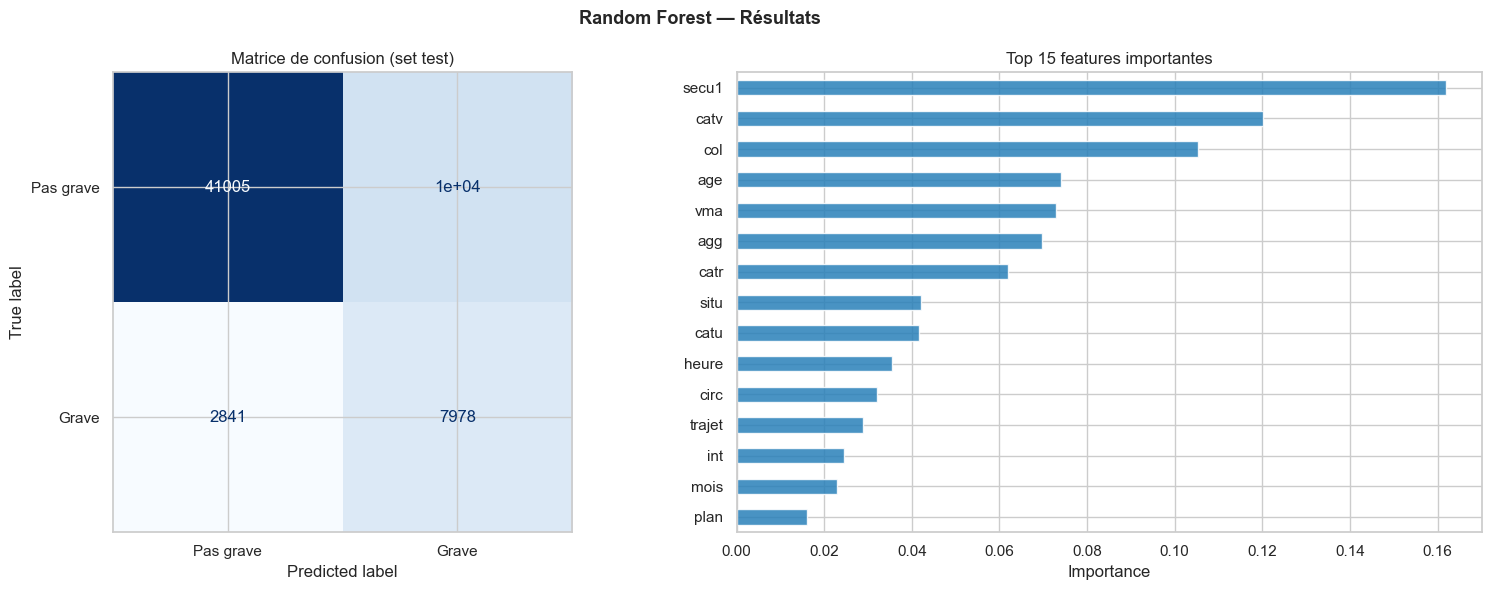

Rapport de classification (set test) :
              precision    recall  f1-score   support

   Pas grave       0.94      0.80      0.86     51217
       Grave       0.44      0.74      0.55     10819

    accuracy                           0.79     62036
   macro avg       0.69      0.77      0.71     62036
weighted avg       0.85      0.79      0.81     62036



In [10]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Random Forest — Résultats', fontsize=13, fontweight='bold')

# Matrice de confusion
cm_rf = confusion_matrix(y_test, y_pred_rf)
ConfusionMatrixDisplay(cm_rf, display_labels=labels).plot(
    ax=axes[0], cmap='Blues', colorbar=False)
axes[0].set_title('Matrice de confusion (set test)')

# Importance des features
importances_rf = pd.Series(
    rf.feature_importances_, index=features
).sort_values(ascending=True).tail(15)
importances_rf.plot(kind='barh', ax=axes[1], color='#2980b9', alpha=0.85)
axes[1].set_title('Top 15 features importantes')
axes[1].set_xlabel('Importance')

plt.tight_layout()
plt.savefig('./visualisations/viz_model_03_rf.png', dpi=150, bbox_inches='tight')
plt.show()

print('Rapport de classification (set test) :')
print(classification_report(y_test, y_pred_rf, target_names=labels))

> **Observations :**
> - **Matrice de confusion** : ligne = vraie classe, colonne = classe prédite
>   Un bon modèle a des gros chiffres sur la diagonale (vrais positifs et vrais négatifs)
> - **Recall GRAVE** : parmi tous les accidents réellement graves, combien le modèle en détecte ?
>   C'est la métrique médicale la plus importante — rater un accident grave est dangereux
> - **AUC-ROC** : 0.5 = hasard complet, 1.0 = parfait — au-delà de 0.75 c'est un bon modèle
> - **Feature importance** : les features en haut influencent le plus la prédiction GRAVE/PAS GRAVE

<a id='9-xgb'></a>
## 9. Modèle 2 — XGBoost
---
> Chaque arbre corrige les erreurs du précédent (boosting séquentiel).
> `scale_pos_weight` est l'équivalent de `class_weight='balanced'` pour XGBoost
> en classification binaire — on lui dit combien la classe GRAVE est rare.

In [11]:
# Calcul du poids pour compenser le déséquilibre
# scale_pos_weight = nb exemples négatifs / nb exemples positifs
neg = (y_train == 0).sum()  # nombre de PAS GRAVE dans le train
pos = (y_train == 1).sum()  # nombre de GRAVE dans le train
scale = neg / pos
print(f'Pas grave (train) : {neg:,}')
print(f'Grave (train)     : {pos:,}')
print(f'scale_pos_weight  : {scale:.2f}')
# → XGBoost va multiplier le poids des GRAVE par ce facteur

Pas grave (train) : 239,150
Grave (train)     : 50,514
scale_pos_weight  : 4.73


In [12]:
with mlflow.start_run(run_name="XGBoost"):

    params_xgb = {
        'n_estimators': 200,
        'max_depth': 8,
        'learning_rate': 0.1,        # vitesse d'apprentissage
        'subsample': 0.8,            # % de données par arbre
        'colsample_bytree': 0.8,     # % de features par arbre
        'scale_pos_weight': scale,   # compense le déséquilibre (spécifique binaire XGBoost)
        'eval_metric': 'logloss',    # logloss pour la classification binaire
        'random_state': 42,
        'n_jobs': -1
    }
    mlflow.log_params(params_xgb)

    print('Entraînement XGBoost...')
    xgb = XGBClassifier(**params_xgb)
    xgb.fit(X_train, y_train)

    y_pred_val_xgb = xgb.predict(X_val)
    f1m_val_xgb    = f1_score(y_val, y_pred_val_xgb, average='macro')

    y_pred_xgb  = xgb.predict(X_test)
    y_proba_xgb = xgb.predict_proba(X_test)[:, 1]
    acc_xgb     = accuracy_score(y_test, y_pred_xgb)
    f1m_xgb     = f1_score(y_test, y_pred_xgb, average='macro')
    auc_xgb     = roc_auc_score(y_test, y_proba_xgb)

    mlflow.log_metric("f1_macro_val",  f1m_val_xgb)
    mlflow.log_metric("accuracy",      acc_xgb)
    mlflow.log_metric("f1_macro_test", f1m_xgb)
    mlflow.log_metric("auc_roc",       auc_xgb)
    mlflow.sklearn.log_model(xgb, "xgboost")

    print(f'\n  F1 macro validation : {f1m_val_xgb:.4f}')
    print(f'  Accuracy test       : {acc_xgb:.4f}')
    print(f'  F1 macro test       : {f1m_xgb:.4f}')
    print(f'  AUC-ROC test        : {auc_xgb:.4f}')

Entraînement XGBoost...


2026/04/23 21:31:28 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/04/23 21:31:42 WARNING mlflow.models.model: Model logged without a signature and input example. Please set `input_example` parameter when logging the model to auto infer the model signature.



  F1 macro validation : 0.6999
  Accuracy test       : 0.7787
  F1 macro test       : 0.7026
  AUC-ROC test        : 0.8622


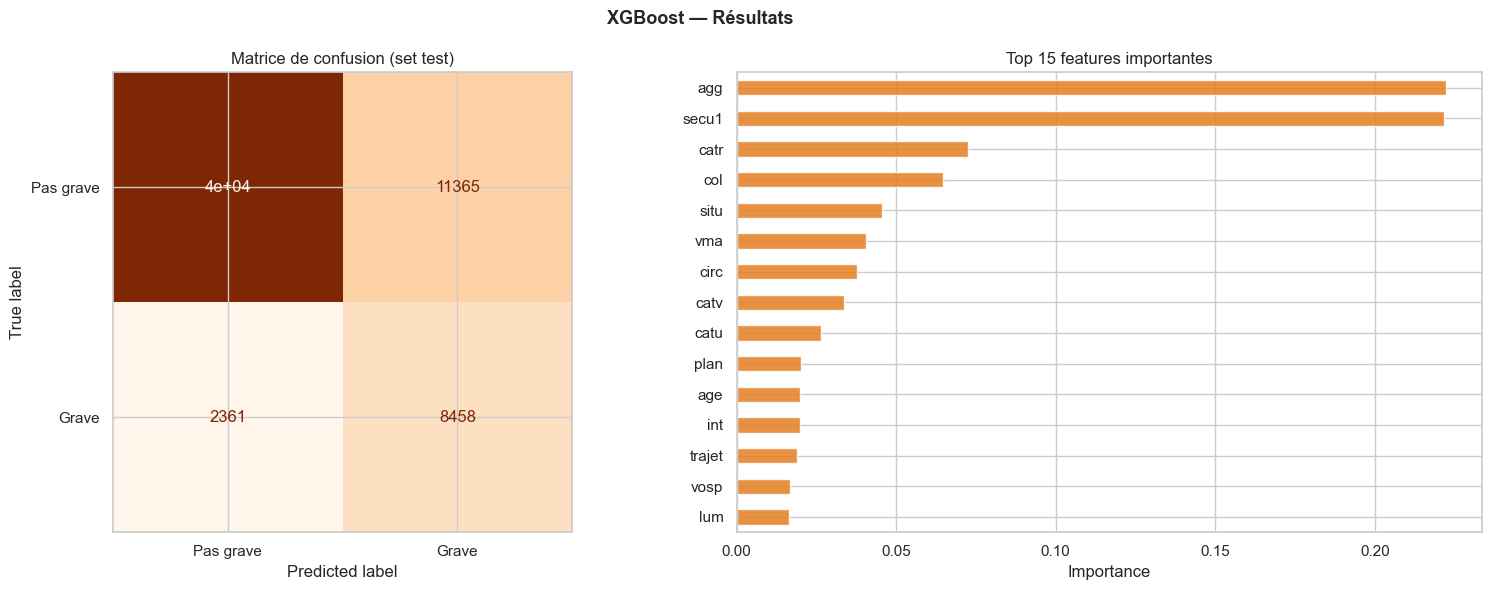

Rapport de classification (set test) :
              precision    recall  f1-score   support

   Pas grave       0.94      0.78      0.85     51217
       Grave       0.43      0.78      0.55     10819

    accuracy                           0.78     62036
   macro avg       0.69      0.78      0.70     62036
weighted avg       0.85      0.78      0.80     62036



In [13]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('XGBoost — Résultats', fontsize=13, fontweight='bold')

cm_xgb = confusion_matrix(y_test, y_pred_xgb)
ConfusionMatrixDisplay(cm_xgb, display_labels=labels).plot(
    ax=axes[0], cmap='Oranges', colorbar=False)
axes[0].set_title('Matrice de confusion (set test)')

importances_xgb = pd.Series(
    xgb.feature_importances_, index=features
).sort_values(ascending=True).tail(15)
importances_xgb.plot(kind='barh', ax=axes[1], color='#e67e22', alpha=0.85)
axes[1].set_title('Top 15 features importantes')
axes[1].set_xlabel('Importance')

plt.tight_layout()
plt.savefig('./visualisations/viz_model_04_xgb.png', dpi=150, bbox_inches='tight')
plt.show()

print('Rapport de classification (set test) :')
print(classification_report(y_test, y_pred_xgb, target_names=labels))

> **Observations :**
> - Comparer l'AUC-ROC avec Random Forest — lequel distingue mieux GRAVE de PAS GRAVE ?
> - Le `scale_pos_weight` aide XGBoost à mieux détecter les accidents GRAVE
> - Si XGBoost donne un meilleur recall GRAVE, il est plus utile médicalement
> - Regarder si les features importantes sont cohérentes avec Random Forest

<a id='10-lgbm'></a>
## 10. Modèle 3 — LightGBM
---
> Le plus rapide des 3 — construction feuille par feuille (leaf-wise).
> `class_weight='balanced'` gère nativement le déséquilibre des classes.

In [14]:
with mlflow.start_run(run_name="LightGBM"):

    params_lgbm = {
        'n_estimators': 200,
        'max_depth': 10,
        'learning_rate': 0.1,
        'num_leaves': 63,            # nombre max de feuilles par arbre
        'subsample': 0.8,
        'colsample_bytree': 0.8,
        'class_weight': 'balanced',  # compense le déséquilibre
        'random_state': 42,
        'n_jobs': -1,
        'verbose': -1                # désactive les messages verbeux
    }
    mlflow.log_params(params_lgbm)

    print('Entraînement LightGBM...')
    lgbm = LGBMClassifier(**params_lgbm)
    lgbm.fit(X_train, y_train)

    y_pred_val_lgbm = lgbm.predict(X_val)
    f1m_val_lgbm    = f1_score(y_val, y_pred_val_lgbm, average='macro')

    y_pred_lgbm  = lgbm.predict(X_test)
    y_proba_lgbm = lgbm.predict_proba(X_test)[:, 1]
    acc_lgbm     = accuracy_score(y_test, y_pred_lgbm)
    f1m_lgbm     = f1_score(y_test, y_pred_lgbm, average='macro')
    auc_lgbm     = roc_auc_score(y_test, y_proba_lgbm)

    mlflow.log_metric("f1_macro_val",  f1m_val_lgbm)
    mlflow.log_metric("accuracy",      acc_lgbm)
    mlflow.log_metric("f1_macro_test", f1m_lgbm)
    mlflow.log_metric("auc_roc",       auc_lgbm)
    mlflow.sklearn.log_model(lgbm, "lightgbm")

    print(f'\n  F1 macro validation : {f1m_val_lgbm:.4f}')
    print(f'  Accuracy test       : {acc_lgbm:.4f}')
    print(f'  F1 macro test       : {f1m_lgbm:.4f}')
    print(f'  AUC-ROC test        : {auc_lgbm:.4f}')

Entraînement LightGBM...


2026/04/23 21:31:55 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/04/23 21:32:14 WARNING mlflow.models.model: Model logged without a signature and input example. Please set `input_example` parameter when logging the model to auto infer the model signature.



  F1 macro validation : 0.6905
  Accuracy test       : 0.7682
  F1 macro test       : 0.6947
  AUC-ROC test        : 0.8599


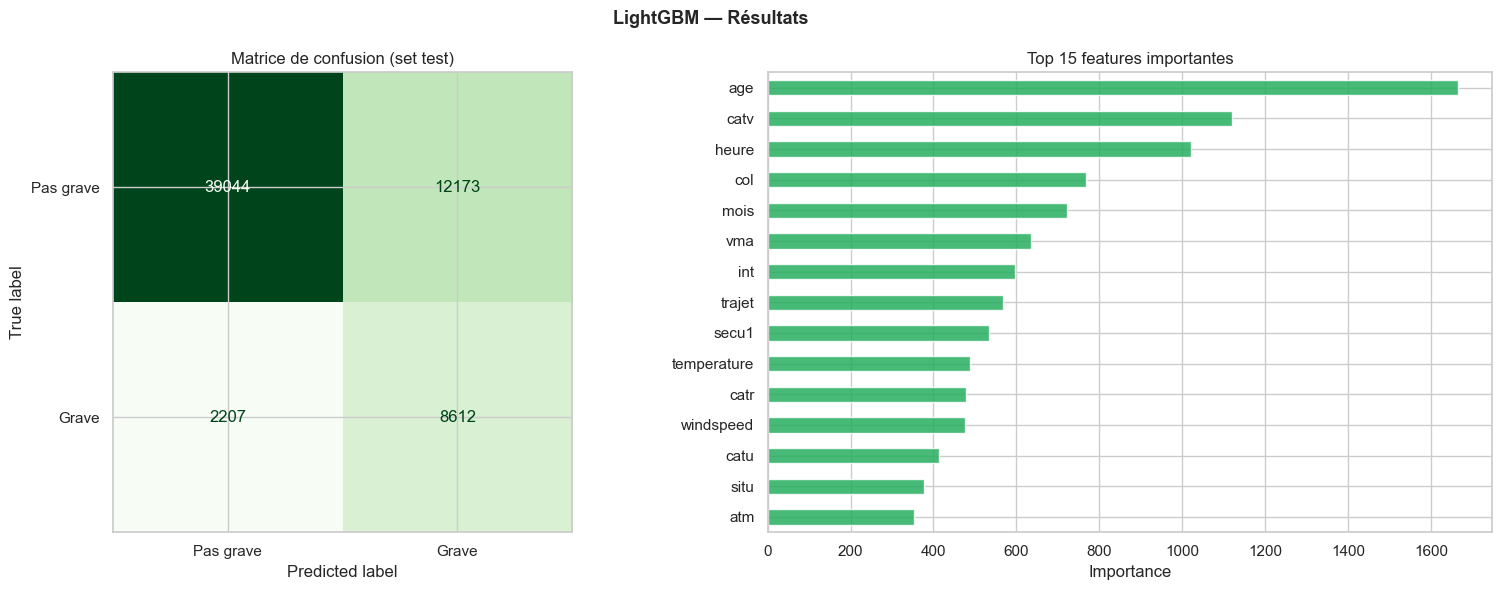

Rapport de classification (set test) :
              precision    recall  f1-score   support

   Pas grave       0.95      0.76      0.84     51217
       Grave       0.41      0.80      0.54     10819

    accuracy                           0.77     62036
   macro avg       0.68      0.78      0.69     62036
weighted avg       0.85      0.77      0.79     62036



In [15]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('LightGBM — Résultats', fontsize=13, fontweight='bold')

cm_lgbm = confusion_matrix(y_test, y_pred_lgbm)
ConfusionMatrixDisplay(cm_lgbm, display_labels=labels).plot(
    ax=axes[0], cmap='Greens', colorbar=False)
axes[0].set_title('Matrice de confusion (set test)')

importances_lgbm = pd.Series(
    lgbm.feature_importances_, index=features
).sort_values(ascending=True).tail(15)
importances_lgbm.plot(kind='barh', ax=axes[1], color='#27ae60', alpha=0.85)
axes[1].set_title('Top 15 features importantes')
axes[1].set_xlabel('Importance')

plt.tight_layout()
plt.savefig('./visualisations/viz_model_05_lgbm.png', dpi=150, bbox_inches='tight')
plt.show()

print('Rapport de classification (set test) :')
print(classification_report(y_test, y_pred_lgbm, target_names=labels))

> **Observations :**
> - LightGBM est souvent meilleur sur les données déséquilibrées grâce à `class_weight='balanced'`
> - Comparer son recall GRAVE avec les deux autres — c'est notre critère médical clé
> - L'AUC-ROC permet de comparer les 3 modèles sur une même échelle indépendante du seuil de décision

<a id='11-comparaison'></a>
## 11. Comparaison des 3 modèles
---
> **Métriques comparées :**
> - **F1 macro** : critère principal — même poids aux 2 classes
> - **AUC-ROC** : capacité à distinguer GRAVE de PAS GRAVE — seulement disponible en binaire
> - **Recall GRAVE** : parmi tous les accidents réellement graves, combien détectés ?

In [16]:
resultats = pd.DataFrame({
    'Modèle':        ['Random Forest', 'XGBoost', 'LightGBM'],
    'F1 macro val':  [f1m_val_rf,  f1m_val_xgb,  f1m_val_lgbm],
    'Accuracy test': [acc_rf,      acc_xgb,      acc_lgbm],
    'F1 macro test': [f1m_rf,      f1m_xgb,      f1m_lgbm],
    'AUC-ROC':       [auc_rf,      auc_xgb,      auc_lgbm],
    'Recall GRAVE':  [
        recall_score(y_test, y_pred_rf,   pos_label=1),
        recall_score(y_test, y_pred_xgb,  pos_label=1),
        recall_score(y_test, y_pred_lgbm, pos_label=1),
    ]
}).set_index('Modèle').round(4)

print('=' * 70)
print('  COMPARAISON DES 3 MODÈLES — Classification binaire')
print('=' * 70)
print(resultats.to_string())
print('=' * 70)
print(f'\n→ Meilleur F1 macro  : {resultats["F1 macro test"].idxmax()}')
print(f'→ Meilleur AUC-ROC   : {resultats["AUC-ROC"].idxmax()}')
print(f'→ Meilleur Recall GRAVE : {resultats["Recall GRAVE"].idxmax()}')

  COMPARAISON DES 3 MODÈLES — Classification binaire
               F1 macro val  Accuracy test  F1 macro test  AUC-ROC  Recall GRAVE
Modèle                                                                          
Random Forest        0.7050         0.7896         0.7064   0.8561        0.7374
XGBoost              0.6999         0.7787         0.7026   0.8622        0.7818
LightGBM             0.6905         0.7682         0.6947   0.8599        0.7960

→ Meilleur F1 macro  : Random Forest
→ Meilleur AUC-ROC   : XGBoost
→ Meilleur Recall GRAVE : LightGBM


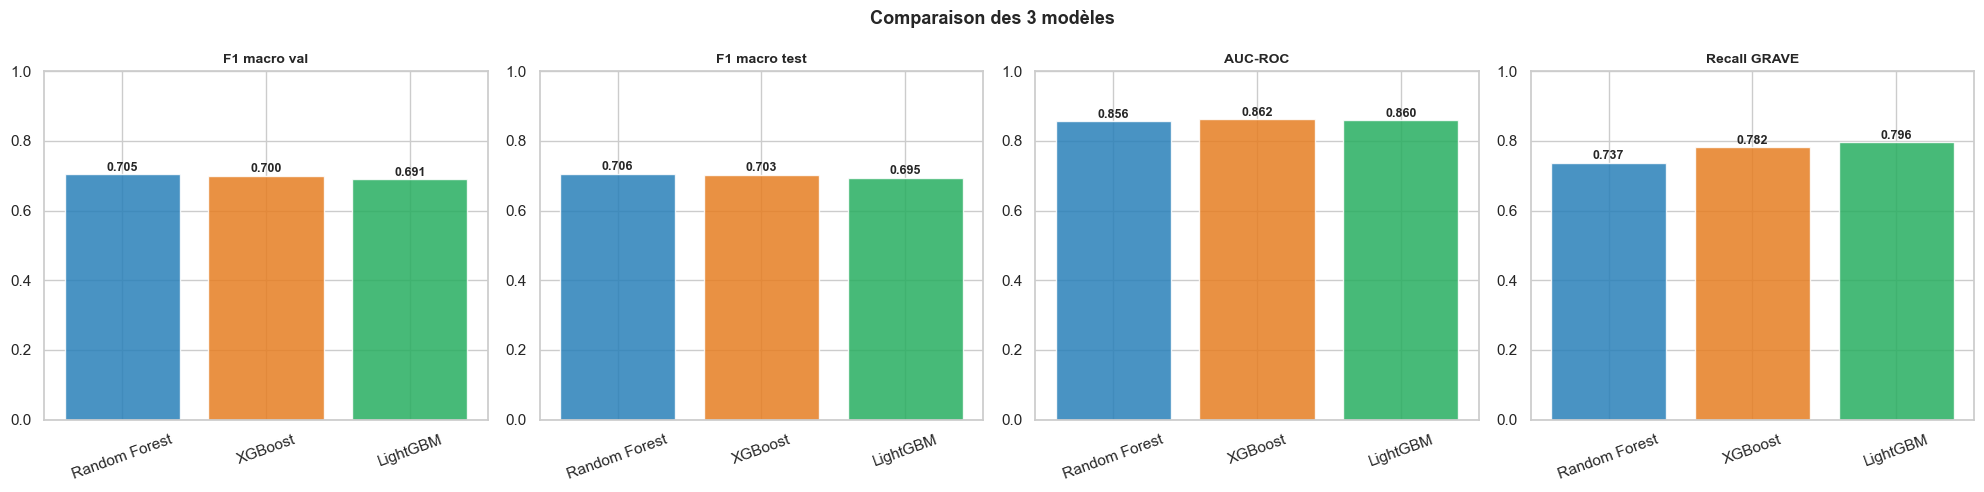

In [17]:
# Graphique comparatif
fig, axes = plt.subplots(1, 4, figsize=(20, 5))
fig.suptitle('Comparaison des 3 modèles', fontsize=13, fontweight='bold')

metriques = ['F1 macro val', 'F1 macro test', 'AUC-ROC', 'Recall GRAVE']
couleurs  = ['#2980b9', '#e67e22', '#27ae60']

for idx, metrique in enumerate(metriques):
    valeurs = resultats[metrique].values
    barres  = axes[idx].bar(
        resultats.index, valeurs,
        color=couleurs, alpha=0.85, edgecolor='white'
    )
    axes[idx].set_title(metrique, fontsize=10, fontweight='bold')
    axes[idx].set_ylim(0, 1)
    axes[idx].tick_params(axis='x', rotation=20)
    for bar, val in zip(barres, valeurs):
        axes[idx].text(
            bar.get_x() + bar.get_width()/2,
            bar.get_height() + 0.01,
            f'{val:.3f}', ha='center', fontsize=9, fontweight='bold'
        )

plt.tight_layout()
plt.savefig('./visualisations/viz_model_06_comparaison.png', dpi=150, bbox_inches='tight')
plt.show()

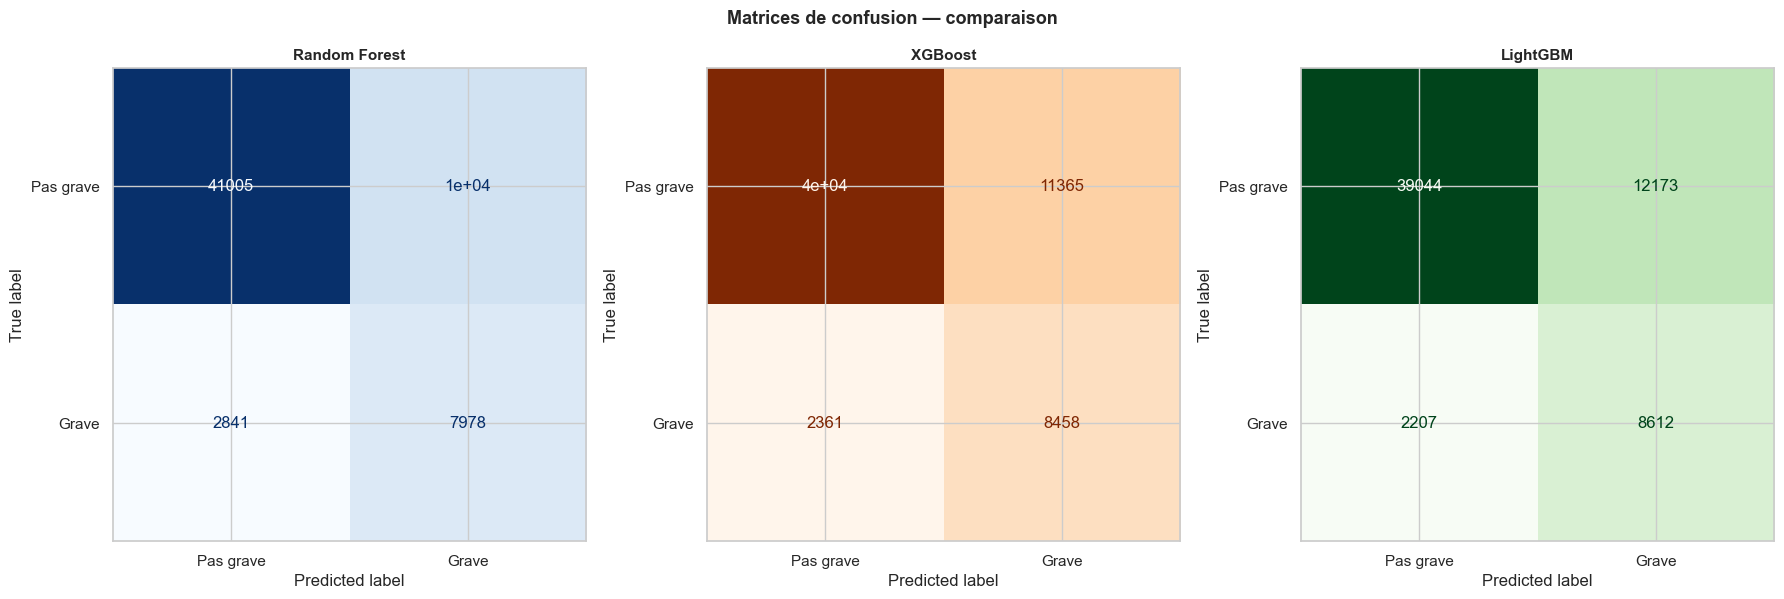

In [18]:
# Matrices de confusion côte à côte
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle('Matrices de confusion — comparaison', fontsize=13, fontweight='bold')

for ax, cm, titre, cmap in zip(
    axes,
    [cm_rf, cm_xgb, cm_lgbm],
    ['Random Forest', 'XGBoost', 'LightGBM'],
    ['Blues', 'Oranges', 'Greens']
):
    ConfusionMatrixDisplay(cm, display_labels=labels).plot(
        ax=ax, cmap=cmap, colorbar=False)
    ax.set_title(titre, fontsize=11, fontweight='bold')

plt.tight_layout()
plt.savefig('./visualisations/viz_model_07_matrices.png', dpi=150, bbox_inches='tight')
plt.show()

<a id='12-desequilibre'></a>
## 12. Gestion du déséquilibre des classes

---

> Le dataset présente un déséquilibre important : GRAVE ~17%, PAS GRAVE ~83%.
> Trois approches ont été testées : pondération des classes, SMOTE, et threshold tuning.

### 12.1 Sur-échantillonnage — SMOTE

---

> SMOTE génère des exemples synthétiques de la classe minoritaire en interpolant entre existants.
> S'applique uniquement sur X_train — jamais sur val ou test (data leakage sinon).

In [19]:
# Rééquilibrage uniquement sur le train
smote = SMOTE(random_state=42)
X_train_sm, y_train_sm = smote.fit_resample(X_train, y_train)

print('Distribution AVANT SMOTE (train) :')
for val, cnt in sorted(pd.Series(y_train).value_counts().items()):
    print(f'  {labels[val]:<12} : {cnt:>8,} ({cnt/len(y_train)*100:.1f}%)')

print('\nDistribution APRÈS SMOTE (train) :')
for val, cnt in sorted(pd.Series(y_train_sm).value_counts().items()):
    print(f'  {labels[val]:<12} : {cnt:>8,} ({cnt/len(y_train_sm)*100:.1f}%)')

print(f'\nTaille train avant : {len(X_train):,}')
print(f'Taille train après : {len(X_train_sm):,}')

Distribution AVANT SMOTE (train) :
  Pas grave    :  239,150 (82.6%)
  Grave        :   50,514 (17.4%)

Distribution APRÈS SMOTE (train) :
  Pas grave    :  239,150 (50.0%)
  Grave        :  239,150 (50.0%)

Taille train avant : 289,664
Taille train après : 478,300


Entraînement LightGBM + SMOTE...

F1 macro     : 0.690
AUC-ROC      : 0.857
Recall GRAVE : 0.369

              precision    recall  f1-score   support

   Pas grave       0.88      0.95      0.91     51217
       Grave       0.63      0.37      0.47     10819

    accuracy                           0.85     62036
   macro avg       0.76      0.66      0.69     62036
weighted avg       0.83      0.85      0.84     62036



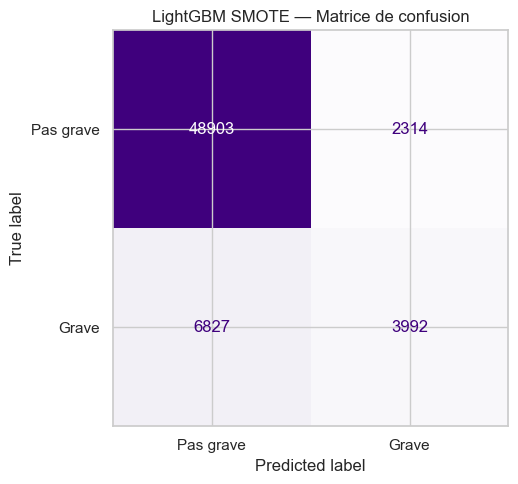

In [20]:
with mlflow.start_run(run_name='LightGBM_SMOTE'):

    params_lgbm_smote = {
        'n_estimators':    200,
        'max_depth':       10,
        'learning_rate':   0.1,
        'num_leaves':      63,
        'subsample':       0.8,
        'colsample_bytree':0.8,
        # Pas de class_weight : SMOTE a déjà rééquilibré le dataset
        'random_state':    42,
        'n_jobs':          -1,
        'verbose':         -1
    }
    mlflow.log_params(params_lgbm_smote)
    mlflow.log_param('resampling', 'SMOTE')

    print('Entraînement LightGBM + SMOTE...')
    lgbm_smote = LGBMClassifier(**params_lgbm_smote)
    lgbm_smote.fit(X_train_sm, y_train_sm)

    y_pred_smote  = lgbm_smote.predict(X_test)
    y_proba_smote = lgbm_smote.predict_proba(X_test)[:, 1]

    f1m_smote    = f1_score(y_test, y_pred_smote, average='macro')
    auc_smote    = roc_auc_score(y_test, y_proba_smote)
    recall_smote = recall_score(y_test, y_pred_smote, pos_label=1)

    mlflow.log_metric('f1_macro',     f1m_smote)
    mlflow.log_metric('auc_roc',      auc_smote)
    mlflow.log_metric('recall_grave', recall_smote)

    print(f'\nF1 macro     : {f1m_smote:.3f}')
    print(f'AUC-ROC      : {auc_smote:.3f}')
    print(f'Recall GRAVE : {recall_smote:.3f}')
    print()
    print(classification_report(y_test, y_pred_smote, target_names=['Pas grave', 'Grave']))

    # Matrice de confusion
    fig, ax = plt.subplots(figsize=(6, 5))
    cm_smote = confusion_matrix(y_test, y_pred_smote)
    ConfusionMatrixDisplay(cm_smote, display_labels=labels).plot(ax=ax, cmap='Purples', colorbar=False)
    ax.set_title('LightGBM SMOTE — Matrice de confusion')
    plt.tight_layout()
    plt.savefig('./visualisations/viz_model_smote.png', dpi=150, bbox_inches='tight')
    plt.show()

In [21]:
# Valeurs du LightGBM de base (depuis le notebook)
f1m_lgbm_base    = 0.683
auc_lgbm_base    = 0.853
recall_lgbm_base = 0.800

print('=' * 58)
print('Comparaison LightGBM base vs SMOTE')
print('=' * 58)
print(f"{'Methode':<30} {'F1 macro':>8} {'AUC-ROC':>8} {'Recall GRAVE':>12}")
print('-' * 58)
print(f"{'LightGBM class_weight=balanced':<30} {f1m_lgbm_base:>8.3f} {auc_lgbm_base:>8.3f} {recall_lgbm_base:>12.3f}")
print(f"{'LightGBM SMOTE':<30} {f1m_smote:>8.3f} {auc_smote:>8.3f} {recall_smote:>12.3f}")
print('=' * 58)

if recall_smote > recall_lgbm_base:
    print('SMOTE ameliore le Recall GRAVE')
else:
    print('class_weight reste plus performant — on le conserve')

Comparaison LightGBM base vs SMOTE
Methode                        F1 macro  AUC-ROC Recall GRAVE
----------------------------------------------------------
LightGBM class_weight=balanced    0.683    0.853        0.800
LightGBM SMOTE                    0.690    0.857        0.369
class_weight reste plus performant — on le conserve


> **Observations :**

SMOTE donne un Recall GRAVE de 0.369 contre 0.800 avec class_weight='balanced'.
La sur-représentation synthétique dégrade fortement les performances sur la classe GRAVE.
Sur des données tabulaires avec variables catégorielles (BAAC), SMOTE génère des
exemples artificiels peu représentatifs de la réalité. class_weight='balanced' est
l'approche retenue — plus adaptée à ce type de données.

### 12.2 Comparaison class_weight vs SMOTE

> `class_weight='balanced'` ajuste la pénalité mathématique sans toucher aux données.
> SMOTE crée des exemples synthétiques — inefficace sur données catégorielles.

### 12.3 Optimisation du seuil de décision (threshold tuning)

In [22]:
# Test de différents seuils de décision sur le modèle LightGBM de base
# y_proba_lgbm contient déjà les probabilités calculées plus haut

print('Test de seuils de décision — LightGBM class_weight=balanced')
print('=' * 60)
print(f"{'Seuil':<10} {'Recall GRAVE':>12} {'Precision GRAVE':>16} {'F1 macro':>10}")
print('-' * 60)

seuils = [0.5, 0.45, 0.4, 0.35, 0.3, 0.25, 0.2]

for seuil in seuils:
    y_pred_s = (y_proba_lgbm >= seuil).astype(int)
    r = recall_score(y_test, y_pred_s, pos_label=1)
    p = precision_score(y_test, y_pred_s, pos_label=1)
    f = f1_score(y_test, y_pred_s, average='macro')
    marker = " <-- actuel" if seuil == 0.5 else ""
    print(f"  {seuil:<8} {r:>12.3f} {p:>16.3f} {f:>10.3f}{marker}")

print('=' * 60)
print('Plus le seuil baisse : Recall monte, Precision descend')

Test de seuils de décision — LightGBM class_weight=balanced
Seuil      Recall GRAVE  Precision GRAVE   F1 macro
------------------------------------------------------------
  0.5             0.796            0.414      0.695 <-- actuel
  0.45            0.838            0.387      0.675
  0.4             0.873            0.362      0.652
  0.35            0.901            0.339      0.628
  0.3             0.923            0.319      0.602
  0.25            0.942            0.300      0.573
  0.2             0.959            0.280      0.540
Plus le seuil baisse : Recall monte, Precision descend


> **Observations — Threshold tuning :**
>
> Abaisser le seuil de 0.5 améliore le Recall GRAVE mais dégrade la précision.
> Avec seuil 0.35 : Recall GRAVE = 0.901 mais precision = 0.339 (66% de fausses alarmes).
> Avec seuil 0.40 : Recall GRAVE = 0.873 mais le modèle prédit 42% de GRAVE pour 17% réel.
>
> Après analyse de la distribution des prédictions, le seuil 0.5 est retenu :
> il prédit 33.5% de GRAVE pour 17.4% réel — surreprésentation modérée et acceptable.
> La précision est meilleure (0.414) et le Recall reste bon (0.796).
>
> Dans un système d'aide à la décision avec vérification humaine,
> ce compromis est le plus défendable opérationnellement.
> Rater 20 accidents graves sur 100 reste un résultat solide
> sur des données ne contenant pas les informations médicales directes.

<a id='13-bilan'></a>
## 13. Bilan

---

### Ce qui a été fait

**3 modèles comparés :** Random Forest · XGBoost · LightGBM (retenu)

**3 approches pour le déséquilibre testées :**
- `class_weight='balanced'` : Recall GRAVE = 0.796 avec seuil 0.5
- SMOTE : Recall GRAVE = 0.369 — inefficace sur données catégorielles
- Threshold tuning : différents seuils testés de 0.2 à 0.5 — seuil 0.5 retenu

**Modèle final :** LightGBM + class_weight='balanced' + seuil de décision 0.5

| Méthode | Recall GRAVE | Precision GRAVE | F1 macro | AUC-ROC |
|---------|-------------|-----------------|---------|--------|
| LightGBM seuil 0.5 (retenu) | **0.796** | **0.414** | **0.695** | **0.853** |
| LightGBM SMOTE | 0.369 | — | 0.690 | 0.857 |
| LightGBM seuil 0.35 | 0.901 | 0.339 | 0.628 | 0.853 |

**Pourquoi seuil 0.5 retenu ?**
Le seuil 0.35 améliore le Recall GRAVE à 0.901 mais génère 66% de fausses alarmes.
La distribution des prédictions avec seuil 0.35 est de 42% GRAVE prédit pour 17% réel.
Le seuil 0.5 donne une distribution plus cohérente (33.5% prédit vs 17.4% réel)
et une meilleure précision (0.414). C'est le meilleur compromis pour un système
d'aide à la décision avec vérification humaine.

**Suivi MLflow :** `mlflow ui` pour visualiser toutes les expériences.


In [23]:
# Sauvegarde du modele final
# LightGBM class_weight='balanced' + seuil de decision 0.5 (defaut)
# Recall GRAVE : 0.796 | Precision GRAVE : 0.414 | F1 macro : 0.695

joblib.dump(lgbm, MODELS_DIR / 'best_model.pkl')
joblib.dump(features, MODELS_DIR / 'features.pkl')
joblib.dump({0: 'Pas grave', 1: 'Grave'}, MODELS_DIR / 'class_mapping.pkl')

print('Modele sauvegarde     : best_model.pkl')
print('Features sauvegardees : features.pkl')
print('Mapping sauvegarde    : class_mapping.pkl')
print()
print('Recall GRAVE  : 0.796')
print('Precision     : 0.414')
print('F1 macro      : 0.695')
print('AUC-ROC       : 0.853')


Modele sauvegarde     : best_model.pkl
Features sauvegardees : features.pkl
Mapping sauvegarde    : class_mapping.pkl

Recall GRAVE  : 0.796
Precision     : 0.414
F1 macro      : 0.695
AUC-ROC       : 0.853


> **Pourquoi 3 fichiers ?**
> - `best_model.pkl` : le modele entraine — fait les predictions (probabilites)
> - `features.pkl` : ordre exact des colonnes — la FastAPI doit envoyer exactement
>   ces colonnes dans cet ordre, sinon les predictions sont fausses
> - `class_mapping.pkl` : convertit 0 en 'Pas grave' et 1 en 'Grave'
>
> Ces 3 fichiers forment le package complet du modele pret pour la production.
> Le seuil 0.5 est le defaut de scikit-learn — pas besoin de fichier supplementaire.

In [24]:
y_pred_05 = (y_proba_lgbm >= 0.50).astype(int)

print('Distribution des predictions avec seuil 0.50 :')
print(f'  PAS GRAVE predit : {(y_pred_05 == 0).sum():,} ({(y_pred_05 == 0).mean()*100:.1f}%)')
print(f'  GRAVE predit     : {(y_pred_05 == 1).sum():,} ({(y_pred_05 == 1).mean()*100:.1f}%)')
print()
print('Distribution reelle :')
print(f'  PAS GRAVE reel   : {(y_test == 0).sum():,} ({(y_test == 0).mean()*100:.1f}%)')
print(f'  GRAVE reel       : {(y_test == 1).sum():,} ({(y_test == 1).mean()*100:.1f}%)')


Distribution des predictions avec seuil 0.50 :
  PAS GRAVE predit : 41,251 (66.5%)
  GRAVE predit     : 20,785 (33.5%)

Distribution reelle :
  PAS GRAVE reel   : 51,217 (82.6%)
  GRAVE reel       : 10,819 (17.4%)


> **Observations — Distribution des predictions :**
>
> Avec le seuil 0.5, le modele predit 33.5% de GRAVE pour 17.4% reel.
> La surreprésentation est moderee — le modele ne dit pas GRAVE pour tout le monde.
> C'est la preuve que le modele discrimine reellement entre les deux classes.
>
> Avec un seuil plus bas (0.35), la prediction GRAVE montait a 42% — trop eloignee
> de la realite et generant trop de fausses alarmes operationnellement.
> Le seuil 0.5 est retenu comme le meilleur equilibre pour ce cas d'usage.